<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning </b></center>

<center><b><h1>Lab - 12</b></center>    
<pre>    


#  Dataset: `Mall_Customers.csv`
## 1. Import Libraries: Import scipy.cluster.hierarchy, AgglomerativeClustering, DBSCAN.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# 2. Load Dataset: Load the customer segmentation dataset.

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 3. Dendrogram: Use scipy to plot a Dendrogram to determine the number of clusters.

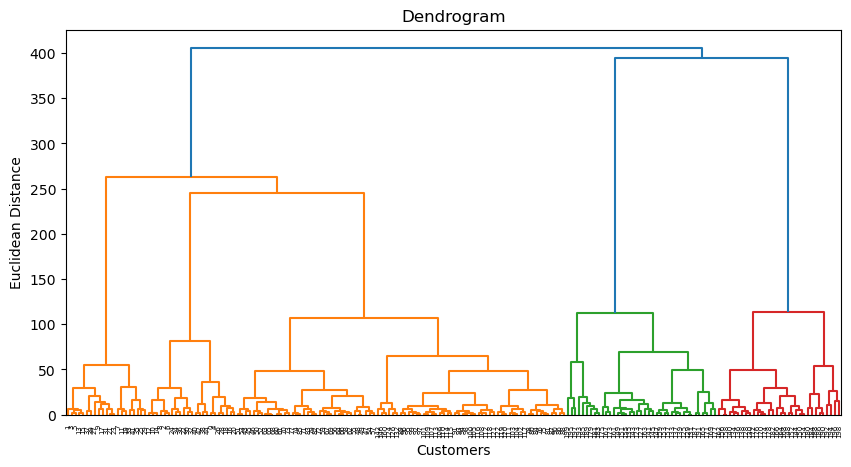

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

plt.figure(figsize=(10,5))

dendrogram(
    linkage(X, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

# 4. Hierarchical Init: Initialize AgglomerativeClustering with the chosen number of clusters

In [7]:
hc = AgglomerativeClustering(
    n_clusters=5
)

# 5. Fit Hierarchical: Fit and predict cluster labels.

In [8]:
hc_labels = hc.fit_predict(X)

print(hc_labels)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


# 6. Visualize Hierarchical: Plot the clusters formed by the Agglomerative model.

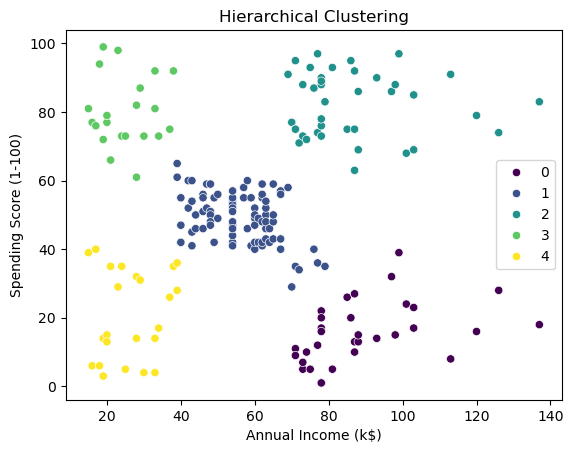

In [9]:
sns.scatterplot(
    x=X.iloc[:,0],
    y=X.iloc[:,1],
    hue=hc_labels,
    palette='viridis'
)

plt.title("Hierarchical Clustering")
plt.show()

# 7. DBSCAN Init: Initialize DBSCAN with eps and min_samples.

In [10]:
dbscan = DBSCAN(
    eps=5,
    min_samples=5
)

# 8. Fit DBSCAN: Fit the model to the data.

In [11]:
db_labels = dbscan.fit_predict(X)
print(db_labels)

[-1  0 -1  0 -1  0 -1 -1 -1  0 -1 -1 -1  0 -1  0 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1 -1 -1  2 -1  4  3  2  3  2 -1  2  3  4  3  2  3  2  3  4 -1  4
  3  4 -1  2 -1  4 -1  4 -1  2 -1  4  3  2  3  2 -1  4 -1  4 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]


# 9. Noise Points: Count how many points were classified as noise (-1).

In [13]:
noise_points = sum(db_labels == -1)
noise_points

np.int64(87)

# 10. Visualize DBSCAN: Plot the clusters found by DBSCAN.

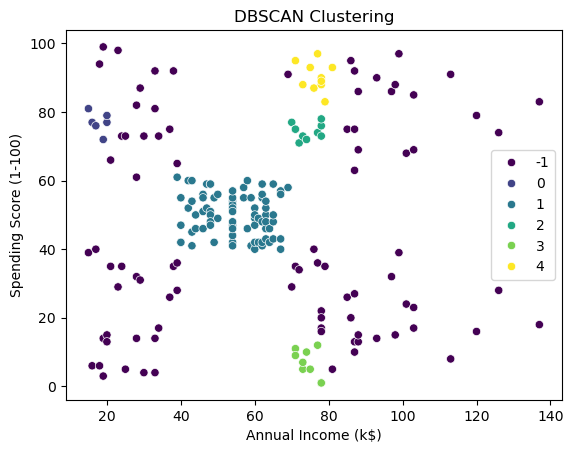

In [14]:
sns.scatterplot(
    x=X.iloc[:,0],
    y=X.iloc[:,1],
    hue=db_labels,
    palette='viridis'
)

plt.title("DBSCAN Clustering")
plt.show()

# 11. Parameter Tuning: Change eps value and re-run DBSCAN to see the effect.

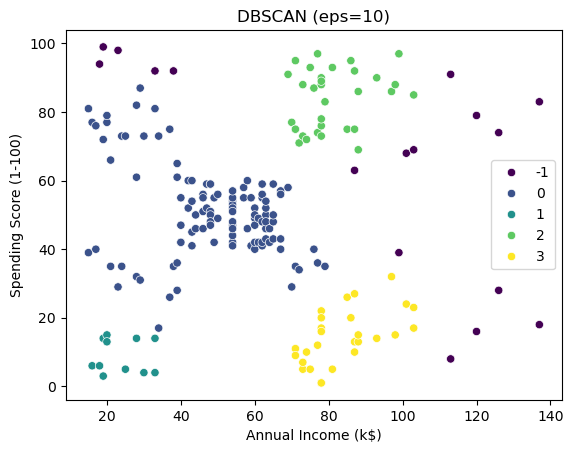

In [15]:
dbscan2 = DBSCAN(
    eps=10,
    min_samples=5
)

db_labels2 = dbscan2.fit_predict(X)

sns.scatterplot(
    x=X.iloc[:,0],
    y=X.iloc[:,1],
    hue=db_labels2,
    palette='viridis'
)

plt.title("DBSCAN (eps=10)")
plt.show()

# 12. Comparison: Compare the shape of clusters between Hierarchical and DBSCAN.

In [16]:
print("Hierarchical Clusters:")
print(set(hc_labels))

print("\nDBSCAN Clusters:")
print(set(db_labels))

Hierarchical Clusters:
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)}

DBSCAN Clusters:
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}


# 13. Analysis: Identify which algorithm handled outliers better.
    
## DBSCAN handles outliers better because it labels them as -1 (noise points).


In [19]:
df['Hierarchical_Cluster'] = hc_labels
profile = df.groupby('Hierarchical_Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean()
profile

,Annual Income (k$),Spending Score (1-100)
Hierarchical_Cluster,,
0,89.406250,15.593750
1,55.811765,49.129412
2,86.538462,82.128205
3,25.095238,80.047619
4,26.304348,20.913043


# 14. Customer Profile: (Optional) Calculate mean income/score for each cluster.

In [ ]:
df['DBSCAN_Cluster'] = db_labels
df.to_csv("Mall_Customers_Clustered.csv",index=False)